# Predict donor impact (allocation focus)

## 1. Problem framing

**Business problem.** When a supporter gives, finance and communications teams want to **describe where the gift is likely to flow** across program areas (Education, Wellbeing, Operations, etc.). A donor-facing or staff dashboard can show an **expected primary program emphasis** before or right after posting, grounded in patterns from past gifts with similar characteristics.

**Stakeholders.** Development staff, donor-relations leads, and (indirectly) donors viewing an impact preview.

**Why it matters.** If the dashboard overstates one program and understates another, stewardship messages can feel inconsistent with later reporting. Reasonable, calibrated expectations reduce confusion and build trust.

**Predictive vs explanatory (textbook framing).** The textbook separates **predictive** goals (generalize to new gifts) from **explanatory** goals (quantify causes). **This notebook is primarily predictive:** we learn a mapping from gift and supporter attributes to a **label derived from realized allocations** in historical data. Later sections discuss **drivers** using model-based importance and simple associations; that is **not** causal proof of why allocations were chosen.

**Target definition.** For each donation, we take the **program area with the largest single allocation line** (ties broken by first row) as `primary_program_area` (six fine-grained labels). For modeling we predict **`primary_program_area_coarse`**: three **domain buckets** — *Resident_programs* (Education + Wellbeing), *Operations_and_facilities* (Operations + Maintenance + Transport), *Outreach_and_growth* (Outreach). Collapsing classes reduces variance per label and usually improves macro-F1 on small, weak-signal data (see feedback in §4 narrative).

**Extra features (signal).** We add: **count of allocation lines** per gift (split complexity), **supporter tenure** (days from supporter `created_at` to `donation_date`), **which numbered gift** this is for that supporter (sequential index), **total gifts by that supporter** in the cohort, and a **rare-level bucket** for `channel_source` (like `campaign_bucket`) to reduce sparse one-hot noise.

**Data quality note.** Fine labels can overlap semantically and are imbalanced; if metrics stay modest, that reflects limited predictable signal in gift metadata—not a failure of the workflow.

**Success criteria.** Out-of-sample **accuracy** and **macro-F1** on a stratified holdout; confusion matrix to see which programs are confused. We favor **interpretable** models over marginal accuracy gains.

**Data.** Synthetic Lighthouse extract: `supporters.csv`, `donations.csv`, `donation_allocations.csv` under `lighthouse_csv_v7/` (run with working directory `ml-pipelines/`).

## 2. Data acquisition, preparation & exploration

We load four tables, validate keys, and build a **reproducible feature table**: one row per donation that has at least one allocation row.

**Join logic.** `donations` → `supporters` on `supporter_id`; allocations aggregated to **primary** `program_area` via `idxmax` on `amount_allocated`. We **do not** use per-allocation geography as a predictor: it is determined at the same time as program splits and would **leak** information about the outcome we are trying to forecast from gift attributes alone.

**Preparation policy.** Median imputation for numeric fields, most-frequent for categoricals inside the sklearn `Pipeline` (fit on train only). Rare `campaign_name` values are grouped into `"(other)"` before modeling. We inspect missingness, target distribution, and gift size outliers; extreme amounts are **winsorized at the 99th percentile (train split)** to limit leverage without dropping rows.

**Reproducibility.** `random_state=42` for splits and tree models; paths resolve from `ml-pipelines/` or repo root.

In [28]:
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

import importlib
import function as fn

importlib.reload(fn)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

ROOT = Path.cwd()
DATA = ROOT / "lighthouse_csv_v7"
if not DATA.is_dir():
    alt = ROOT / "ml-pipelines" / "lighthouse_csv_v7"
    if alt.is_dir():
        DATA = alt
assert DATA.is_dir(), "Run from ml-pipelines/ (or repo root with ml-pipelines/lighthouse_csv_v7)."

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("Data dir:", DATA.resolve())


Data dir: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/lighthouse_csv_v7


In [29]:
from db_config import USE_DB, engine, text

TRUTHY = {"1", "true", "yes", "t", "y"}
FALSY = {"0", "false", "no", "f", "n"}
BOOL_STRINGS = TRUTHY | FALSY


def load_table(table_name: str, csv_filename: str, parse_dates=None, **kwargs):
    """Load from Azure SQL when USE_DB=True, else CSV under lighthouse_csv_v7."""
    import os

    if USE_DB:
        df = pd.read_sql_table(table_name, engine)
        date_set = set(parse_dates or [])
        for col in date_set:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
        for col in df.select_dtypes(include="object").columns:
            if col in date_set:
                continue
            non_null = df[col].notna().sum()
            if non_null == 0:
                continue
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().sum() == non_null:
                df[col] = converted
                continue
            unique_lower = {str(v).lower() for v in df[col].dropna().unique()}
            if unique_lower <= BOOL_STRINGS:
                df[col] = df[col].map(
                    lambda x: 1
                    if str(x).lower() in TRUTHY
                    else (0 if pd.notna(x) else pd.NA)
                ).astype("Int64")
        df.columns = [str(c) for c in df.columns]
        return df
    csv_path = DATA / csv_filename
    return pd.read_csv(csv_path, parse_dates=parse_dates or [], **kwargs)


PROGRAM_AREA_COARSE = {
    "Education": "Resident_programs",
    "Wellbeing": "Resident_programs",
    "Operations": "Operations_and_facilities",
    "Maintenance": "Operations_and_facilities",
    "Transport": "Operations_and_facilities",
    "Outreach": "Outreach_and_growth",
}


def build_donation_impact_frame() -> pd.DataFrame:
    """Prep: fine target `primary_program_area`, coarse `primary_program_area_coarse`, engineered features."""
    supporters = load_table(
        "supporters",
        "supporters.csv",
        parse_dates=["created_at", "first_donation_date"],
    )
    donations = load_table("donations", "donations.csv", parse_dates=["donation_date"])
    alloc = load_table(
        "donation_allocations",
        "donation_allocations.csv",
        parse_dates=["allocation_date"],
    )
    idx = alloc.groupby("donation_id")["amount_allocated"].idxmax()
    primary = alloc.loc[idx, ["donation_id", "program_area"]].rename(
        columns={"program_area": "primary_program_area"}
    )
    n_alloc = alloc.groupby("donation_id").size().rename("n_allocation_lines").reset_index()

    df = donations.merge(primary, on="donation_id", how="inner")
    df = df.merge(n_alloc, on="donation_id", how="left")
    df["n_allocation_lines"] = df["n_allocation_lines"].fillna(1).astype(int)

    df = df.merge(
        supporters[
            [
                "supporter_id",
                "display_name",
                "created_at",
                "supporter_type",
                "relationship_type",
                "region",
                "country",
                "acquisition_channel",
            ]
        ],
        on="supporter_id",
        how="left",
        suffixes=("", "_supp"),
    )

    df["gift_amount_php"] = df["amount"].fillna(df["estimated_value"])
    df["campaign_name"] = df["campaign_name"].fillna("(none)").astype(str)
    df["log1p_gift"] = np.log1p(df["gift_amount_php"].clip(lower=0))

    vc = df["campaign_name"].value_counts()
    rare = set(vc[vc < 5].index)
    df["campaign_bucket"] = df["campaign_name"].where(
        ~df["campaign_name"].isin(rare), "(other)"
    )

    ch = df["channel_source"].fillna("(missing)").astype(str)
    ch_vc = ch.value_counts()
    ch_rare = set(ch_vc[ch_vc < 5].index)
    df["channel_bucket"] = ch.where(~ch.isin(ch_rare), "(other)")

    df["primary_program_area_coarse"] = (
        df["primary_program_area"].map(PROGRAM_AREA_COARSE).fillna("Operations_and_facilities")
    )
    df["is_resident_facing_program"] = df["primary_program_area"].isin(
        ["Education", "Wellbeing"]
    ).astype(int)

    df = df.sort_values(["supporter_id", "donation_date", "donation_id"])
    df["supporter_donation_seq"] = df.groupby("supporter_id").cumcount() + 1
    df["supporter_gift_count_in_cohort"] = df.groupby("supporter_id")["donation_id"].transform(
        "count"
    )

    created = pd.to_datetime(df["created_at"])
    ddate = pd.to_datetime(df["donation_date"])
    df["days_since_supporter_created"] = (ddate.dt.normalize() - created.dt.normalize()).dt.days
    med_days = float(df["days_since_supporter_created"].median())
    df["days_since_supporter_created"] = df["days_since_supporter_created"].fillna(med_days)

    df.columns = [str(c) for c in df.columns]
    return df


raw = build_donation_impact_frame()
print("Rows:", len(raw), "| donations with allocations")
print("Fine primary_program_area:")
print(raw["primary_program_area"].value_counts())
print("Coarse primary_program_area_coarse (model target):")
print(raw["primary_program_area_coarse"].value_counts())

Rows: 420 | donations with allocations
Fine primary_program_area:
primary_program_area
Operations     100
Education       89
Wellbeing       83
Transport       66
Maintenance     42
Outreach        40
Name: count, dtype: int64
Coarse primary_program_area_coarse (model target):
primary_program_area_coarse
Operations_and_facilities    208
Resident_programs            172
Outreach_and_growth           40
Name: count, dtype: int64


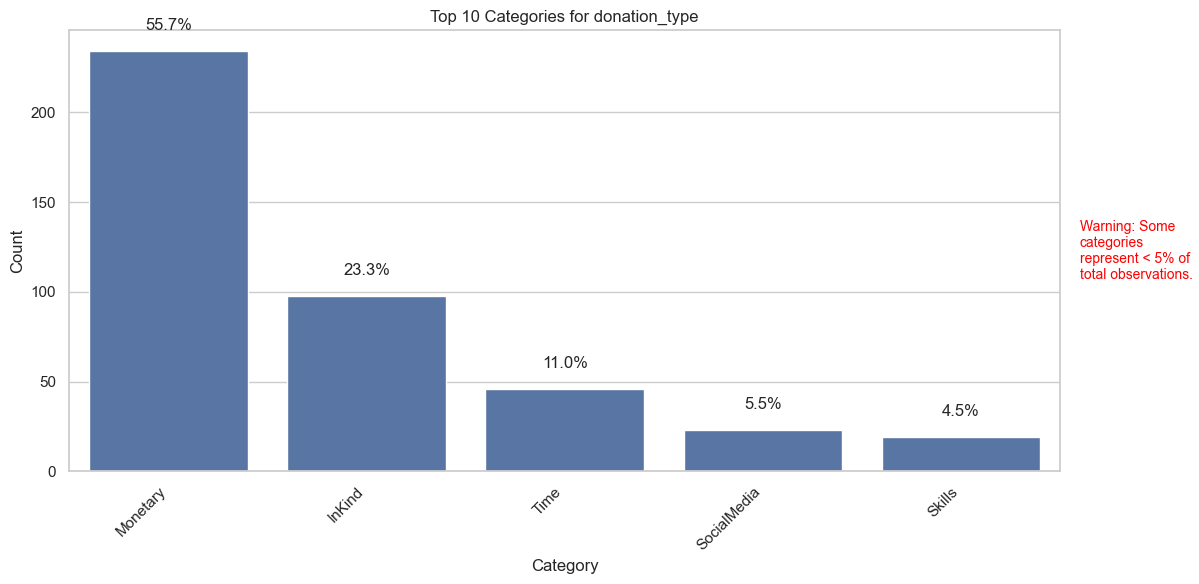

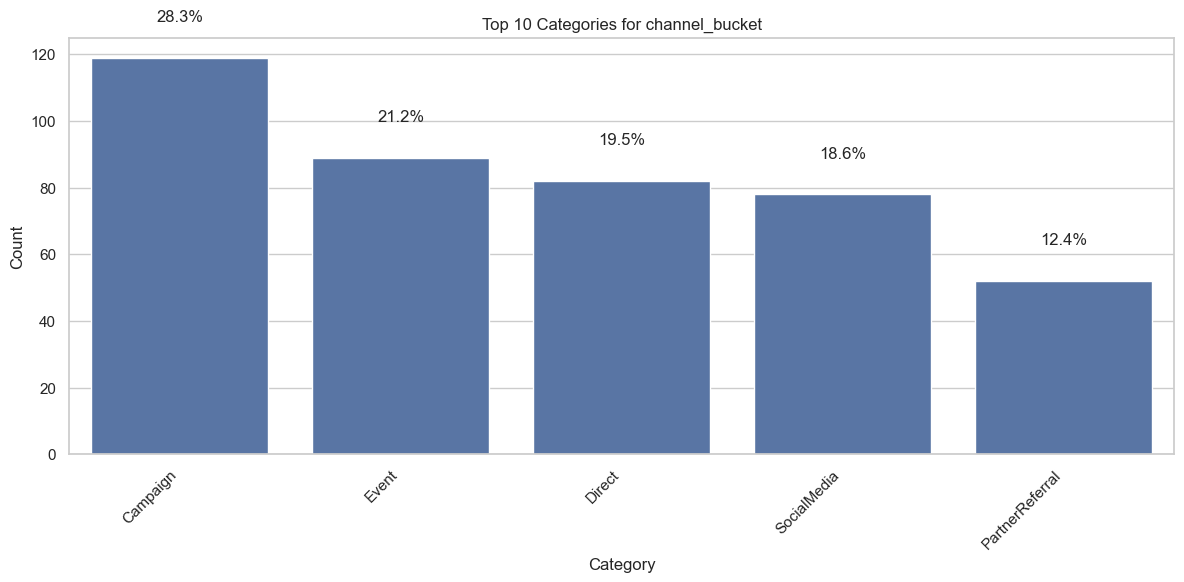

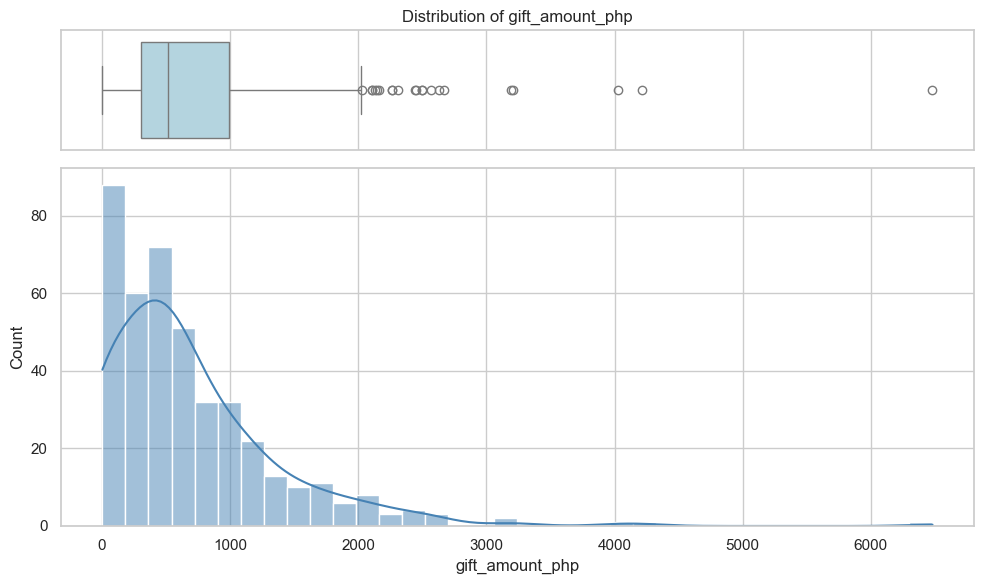

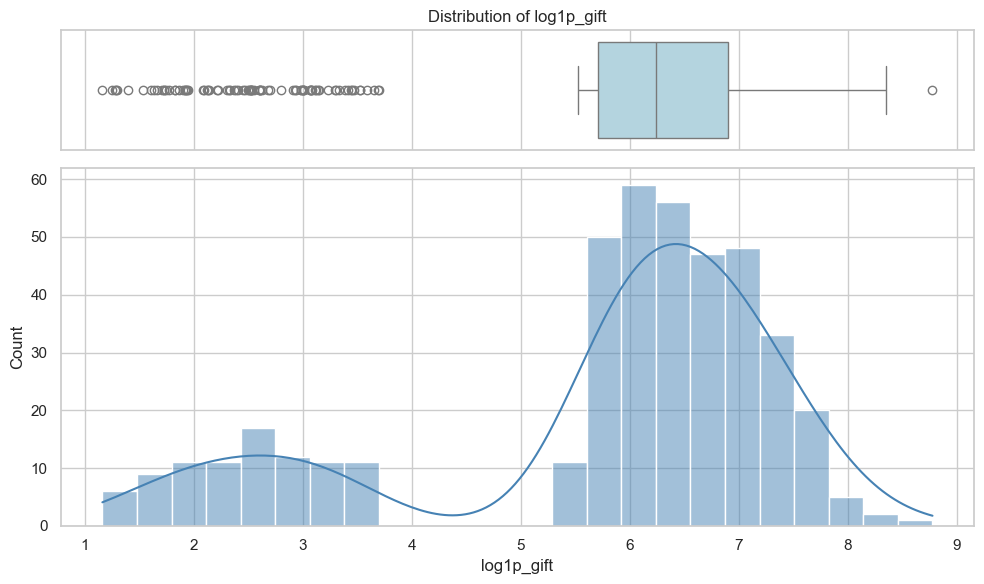

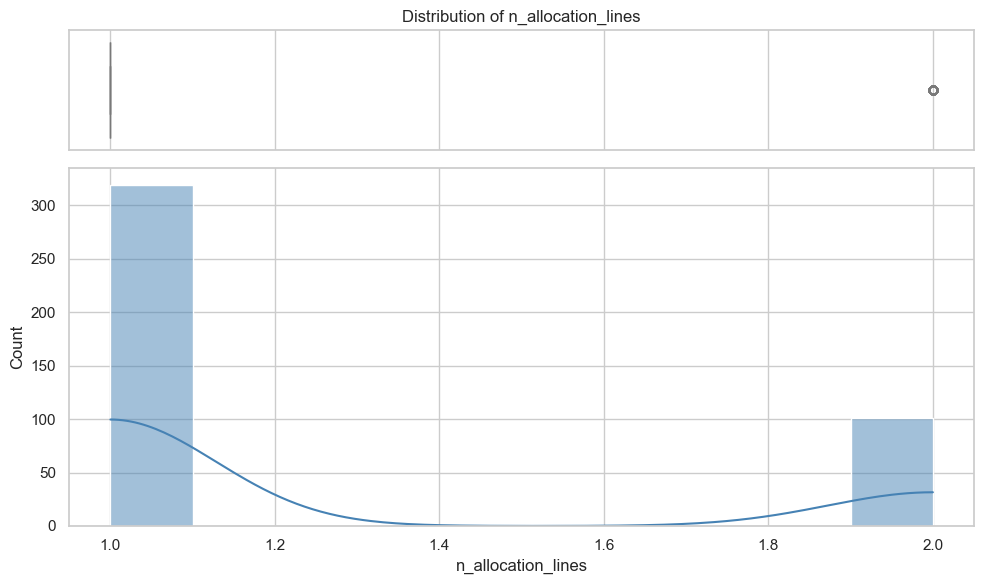

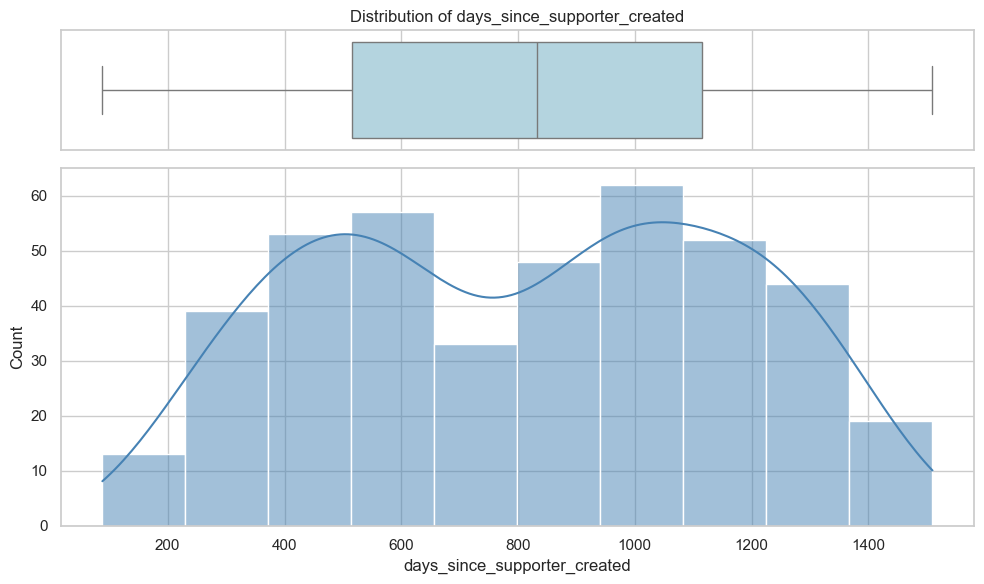

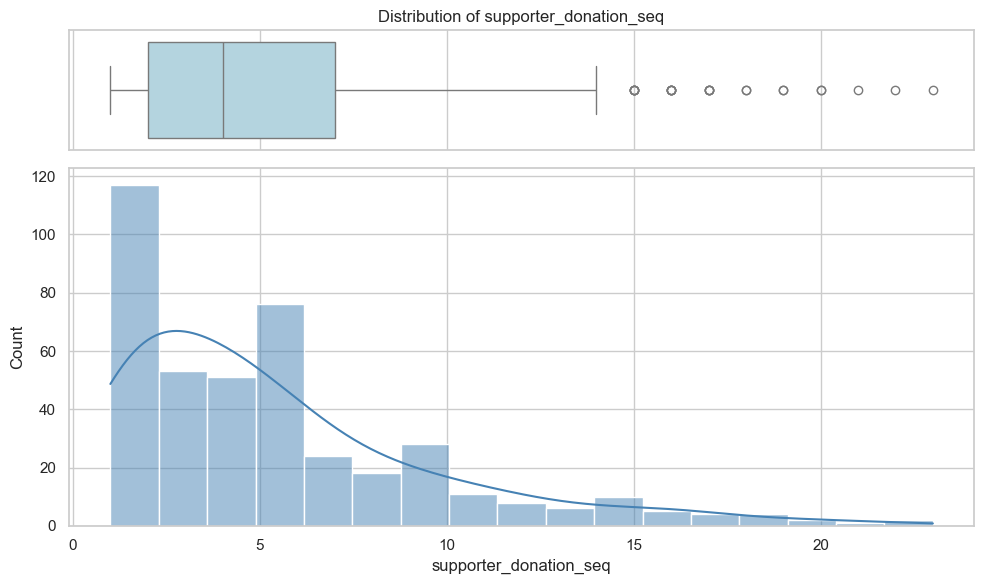

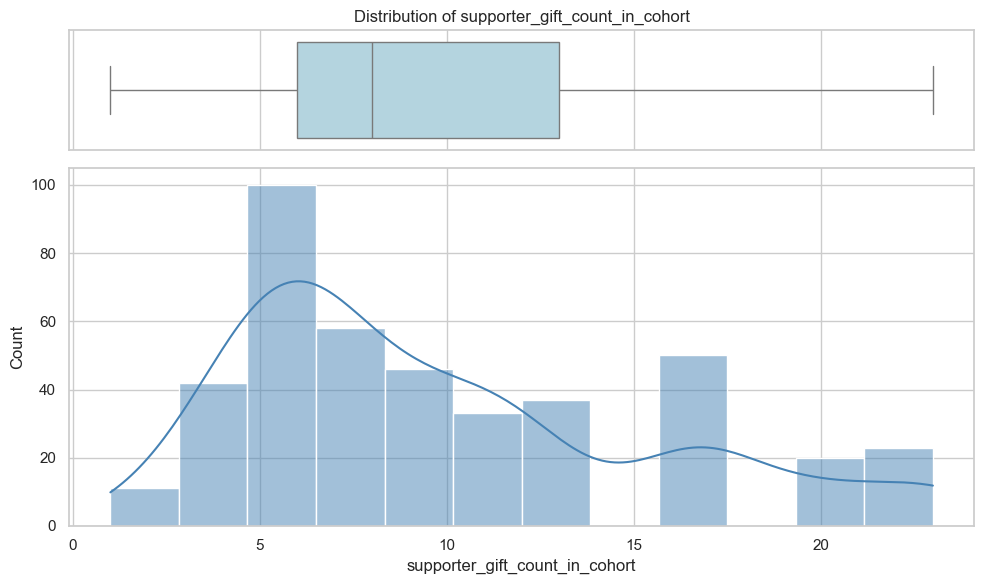

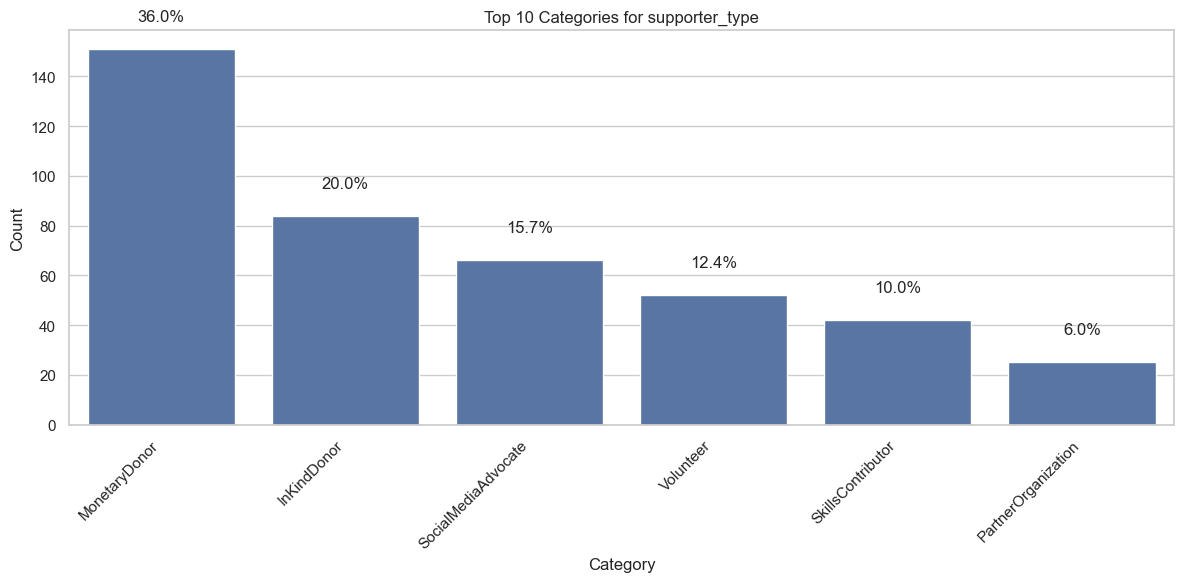

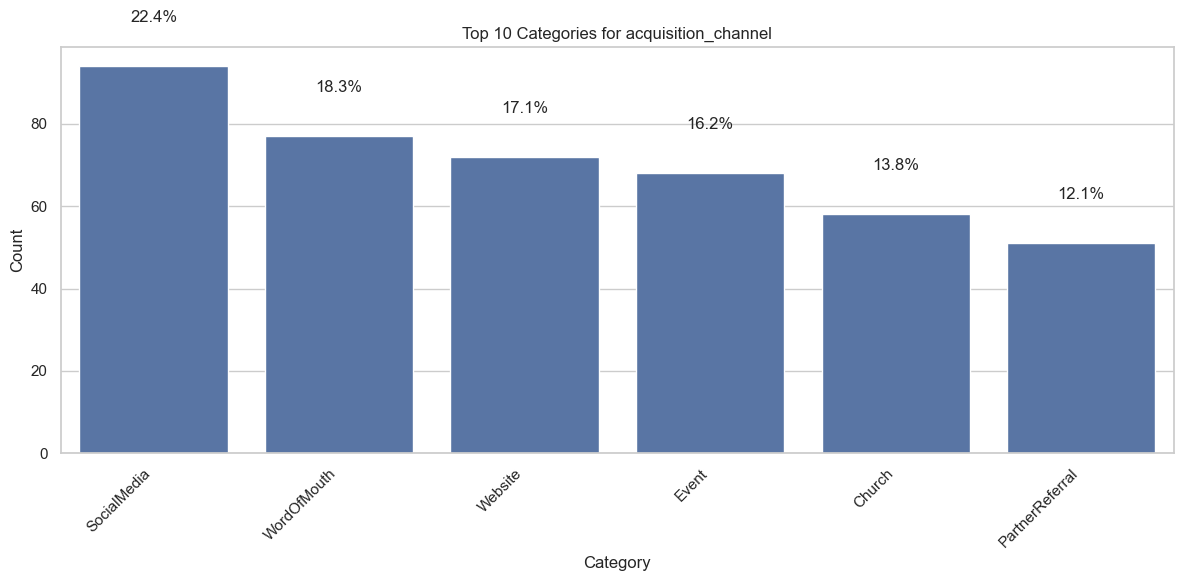

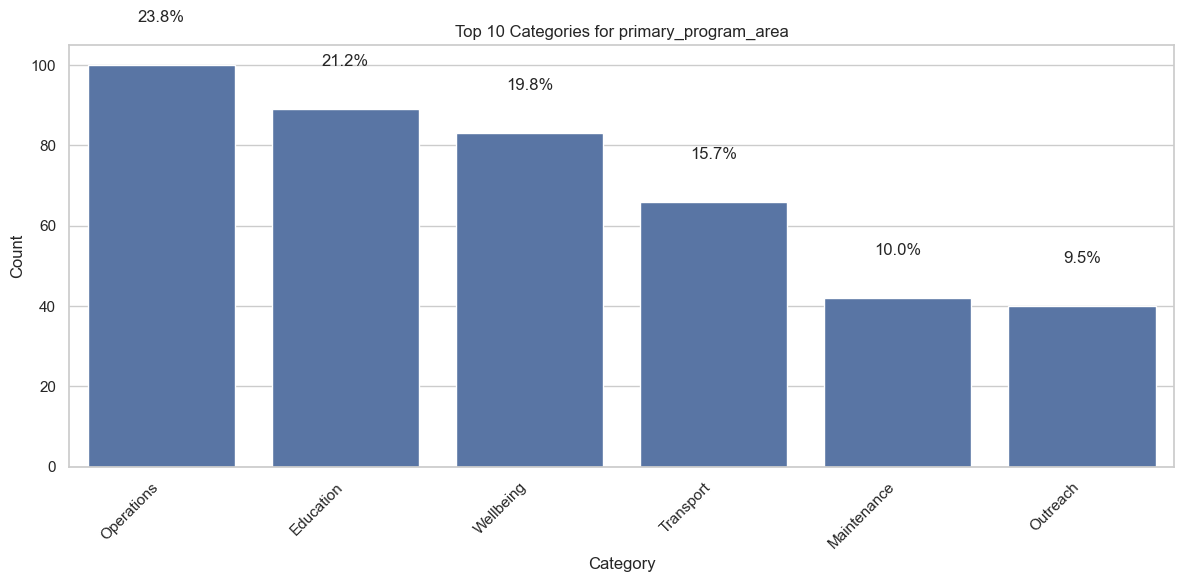

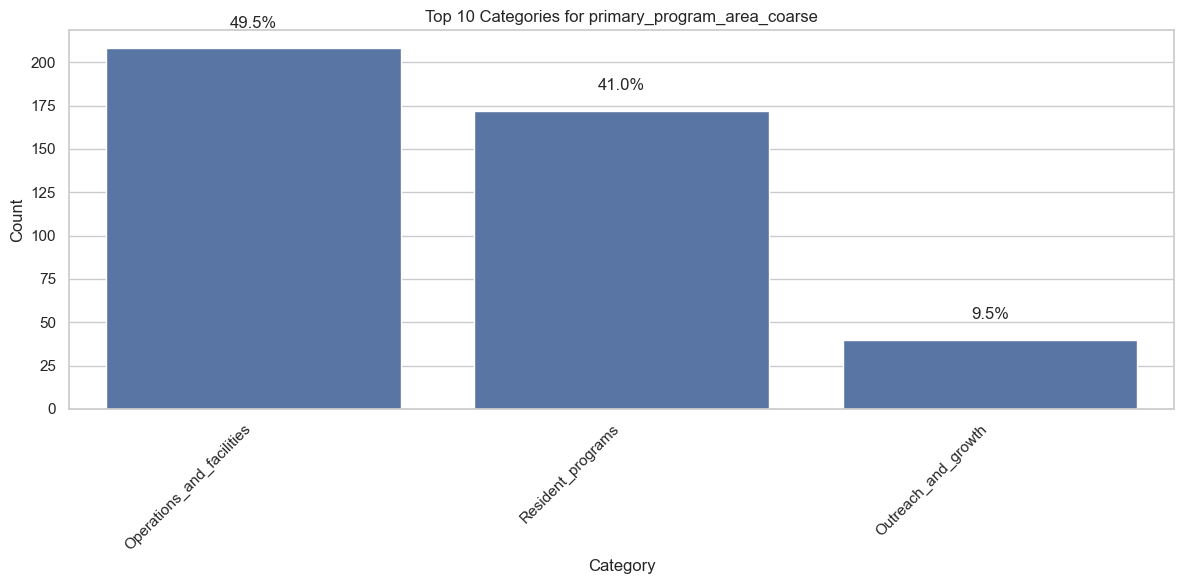

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
donation_type,object,420,0,5,Monetary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_bucket,object,420,0,5,Campaign,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_recurring,bool,420,0,2,True,False,NaN,NaN,NaN,True,0.502381,NaN,NaN,NaN
gift_amount_php,float64,420,0,390,300.0,2.2,300.0,514.16,989.7225,6481.54,699.30431,713.251586,2.538575,12.469335
log1p_gift,float64,420,0,390,5.70711,1.163151,5.70711,6.244469,6.898433,8.776868,5.712833,1.767576,-1.147459,0.106826
n_allocation_lines,int64,420,0,2,1,1,1.0,1.0,1.0,2,1.240476,0.427882,1.218866,-0.51685
days_since_supporter_created,int64,420,0,358,1397,88,515.0,832.5,1116.0,1510,814.542857,354.090243,-0.041142,-1.167834
supporter_donation_seq,int64,420,0,23,1,1,2.0,4.0,7.0,23,5.466667,4.312532,1.445448,2.017862
supporter_gift_count_in_cohort,int64,420,0,17,6,1,6.0,8.0,13.0,23,9.933333,5.596226,0.862404,-0.232653
supporter_type,object,420,0,6,MonetaryDonor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
from IPython.display import display

# Automated univariate summary (Ch. 6 style)
explore_cols = [
    "donation_type",
    "channel_bucket",
    "is_recurring",
    "gift_amount_php",
    "log1p_gift",
    "n_allocation_lines",
    "days_since_supporter_created",
    "supporter_donation_seq",
    "supporter_gift_count_in_cohort",
    "supporter_type",
    "acquisition_channel",
    "primary_program_area",
    "primary_program_area_coarse",
]
uni = fn.univariate(raw[explore_cols].copy())
display(uni)

/var/folders/nr/q0g7khb57sx4s3wnnlhwv1wr0000gn/T/ipykernel_99794/3862317027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw, y="primary_program_area", order=order_f, ax=axes[0], palette="crest")
/var/folders/nr/q0g7khb57sx4s3wnnlhwv1wr0000gn/T/ipykernel_99794/3862317027.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


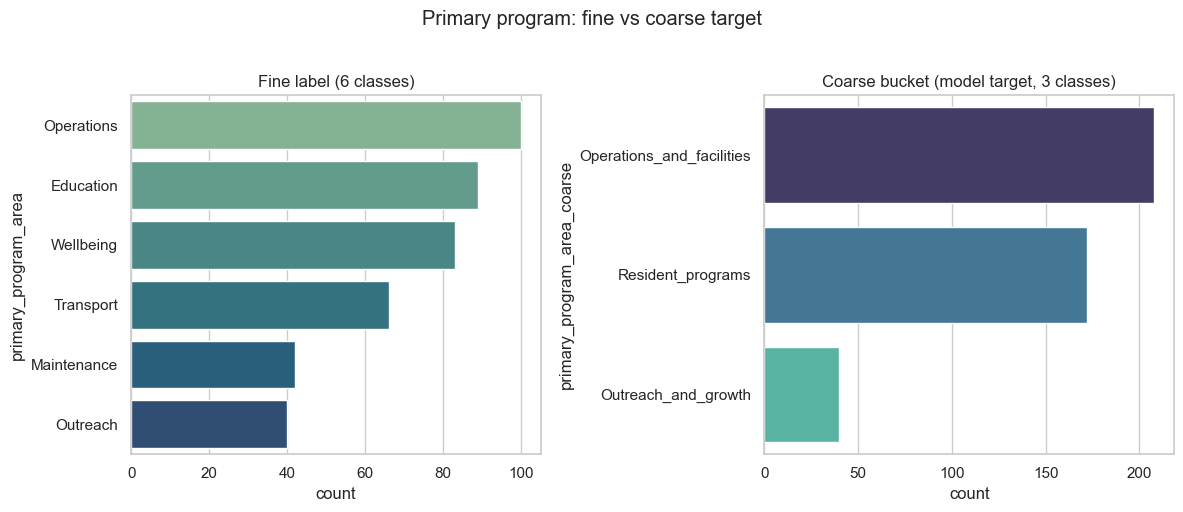

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order_f = raw["primary_program_area"].value_counts().index
sns.countplot(data=raw, y="primary_program_area", order=order_f, ax=axes[0], palette="crest")
axes[0].set_title("Fine label (6 classes)")
order_c = raw["primary_program_area_coarse"].value_counts().index
sns.countplot(
    data=raw, y="primary_program_area_coarse", order=order_c, ax=axes[1], palette="mako"
)
axes[1].set_title("Coarse bucket (model target, 3 classes)")
fig.suptitle("Primary program: fine vs coarse target", y=1.02)
plt.tight_layout()
plt.show()

**Exploration takeaways.** Fine-grained classes are imbalanced; coarse buckets rebalance somewhat. Gift amounts are right-skewed; we use `log1p_gift` and winsorize `gift_amount_php` plus the extra numeric features at the **train** 99th percentile after the split.

## 3. Modeling & feature selection

**Textbook alignment (IS 455 / Keith).** This section mirrors the sequence used in `donor-retention.ipynb`:
- **Ch. 13 — Classification:** Multiclass labels (`primary_program_area_coarse`, three buckets); stratified split; `f1_macro` for tuning. Fine-grained `primary_program_area` kept for QA and dashboards that need the original six-way label.
- **Ch. 14 — Ensemble methods:** **Random forest** and **gradient boosting** variants (`HistGradientBoostingClassifier`, `GradientBoostingClassifier`) plus a **multiclass logistic regression** linear baseline (`solver='lbfgs'`).
- **Ch. 15 — Model evaluation, selection & tuning:** **`GridSearchCV`** with **`StratifiedKFold`** (3 folds) optimizes **`f1_macro`** on training data only; the **winner** is chosen by **CV score**, then evaluated on the **held-out** test set (no peeking during grid search).
- **Ch. 16 — Feature selection:** (1) *Embedded* selection via tree splits / regularized logit. (2) *Comparative* selection by picking the best-performing algorithm. (3) *Optional filter* in **§5b** after permutation importance: drop raw columns with **negative** importance and **refit the winning family** only if **test `f1_macro` does not worsen** (same pattern as donor-retention §5b).

**Features (no leakage).** Same as before: posted-gift and supporter attributes only; no allocation-line geography or amounts as predictors.

**Train/test.** Stratified 80/20 on `primary_program_area_coarse`.


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)

feature_cols = [
    "gift_amount_php",
    "log1p_gift",
    "n_allocation_lines",
    "days_since_supporter_created",
    "supporter_donation_seq",
    "supporter_gift_count_in_cohort",
    "donation_type",
    "channel_bucket",
    "is_recurring",
    "campaign_bucket",
    "supporter_type",
    "relationship_type",
    "region",
    "country",
    "acquisition_channel",
]

X = raw[feature_cols].copy()
y = raw["primary_program_area_coarse"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

cap = float(X_train["gift_amount_php"].quantile(0.99))
X_train = X_train.copy()
X_test = X_test.copy()
X_train["gift_amount_php"] = X_train["gift_amount_php"].clip(upper=cap)
X_test["gift_amount_php"] = X_test["gift_amount_php"].clip(upper=cap)
X_train["log1p_gift"] = np.log1p(X_train["gift_amount_php"].clip(lower=0))
X_test["log1p_gift"] = np.log1p(X_test["gift_amount_php"].clip(lower=0))

extra_num = [
    "n_allocation_lines",
    "days_since_supporter_created",
    "supporter_donation_seq",
    "supporter_gift_count_in_cohort",
]
extra_caps = {}
for col in extra_num:
    cap_c = float(X_train[col].quantile(0.99))
    extra_caps[col] = cap_c
    X_train[col] = X_train[col].clip(upper=cap_c)
    X_test[col] = X_test[col].clip(upper=cap_c)

numeric_features = ["gift_amount_php", "log1p_gift"] + extra_num
categorical_features = [c for c in feature_cols if c not in numeric_features]


def make_preprocessors(num_cols, cat_cols):
    # Tree: impute + OHE (no scaling). Logistic: impute + scale numerics + OHE.
    tree_prep = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "oh",
                            OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse_output=False),
                        ),
                    ]
                ),
                cat_cols,
            ),
        ]
    )
    scaled_prep = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "oh",
                            OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse_output=False),
                        ),
                    ]
                ),
                cat_cols,
            ),
        ]
    )
    return tree_prep, scaled_prep


tree_prep, scaled_prep = make_preprocessors(numeric_features, categorical_features)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pipe_log = Pipeline(
    steps=[
        ("prep", scaled_prep),
        (
            "clf",
            LogisticRegression(
                max_iter=4000,
                solver="lbfgs",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
param_log = {"clf__C": [0.1, 1.0, 10.0]}

pipe_rf = Pipeline(
    steps=[
        ("prep", tree_prep),
        (
            "clf",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=1,
            ),
        ),
    ]
)
param_rf = {
    "clf__n_estimators": [150, 300],
    "clf__max_depth": [8, 12, None],
    "clf__min_samples_leaf": [2, 4],
}

pipe_hgb = Pipeline(
    steps=[
        ("prep", tree_prep),
        (
            "clf",
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)
param_hgb = {
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [None, 5],
    "clf__max_iter": [200, 300],
}

pipe_gbm = Pipeline(
    steps=[
        ("prep", tree_prep),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
)
param_gbm = {
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 5],
    "clf__n_estimators": [100, 150],
}

gs_log = GridSearchCV(
    pipe_log,
    param_log,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    refit=True,
)
gs_rf = GridSearchCV(
    pipe_rf,
    param_rf,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    refit=True,
)
gs_hgb = GridSearchCV(
    pipe_hgb,
    param_hgb,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    refit=True,
)
gs_gbm = GridSearchCV(
    pipe_gbm,
    param_gbm,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    refit=True,
)

print("Tuning logistic regression (GridSearchCV, f1_macro)...")
gs_log.fit(X_train, y_train)
print("Tuning random forest...")
gs_rf.fit(X_train, y_train)
print("Tuning HistGradientBoosting...")
gs_hgb.fit(X_train, y_train)
print("Tuning GradientBoosting...")
gs_gbm.fit(X_train, y_train)

cv_results = pd.DataFrame(
    [
        {"model": "logistic", "cv_f1_macro": gs_log.best_score_, "best_params": gs_log.best_params_},
        {"model": "random_forest", "cv_f1_macro": gs_rf.best_score_, "best_params": gs_rf.best_params_},
        {"model": "hist_gradient_boosting", "cv_f1_macro": gs_hgb.best_score_, "best_params": gs_hgb.best_params_},
        {"model": "gradient_boosting", "cv_f1_macro": gs_gbm.best_score_, "best_params": gs_gbm.best_params_},
    ]
).sort_values("cv_f1_macro", ascending=False)

display(cv_results)

grids = {
    "logistic": gs_log,
    "random_forest": gs_rf,
    "hist_gradient_boosting": gs_hgb,
    "gradient_boosting": gs_gbm,
}

best_name = cv_results.iloc[0]["model"]
best_gs = grids[best_name]
clf_pipe = best_gs.best_estimator_

print("\nSelected model (best CV macro-F1):", best_name)
print("CV f1_macro (mean):", float(best_gs.best_score_))
print("Best params:", best_gs.best_params_)

print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print("Winsor cap (gift_amount_php p99, train):", cap)


Tuning logistic regression (GridSearchCV, f1_macro)...
Tuning random forest...
Tuning HistGradientBoosting...
Tuning GradientBoosting...


,model,cv_f1_macro,best_params
1,random_forest,0.384160,"{'clf__max_depth': 8, 'clf__min_samples_leaf':..."
2,hist_gradient_boosting,0.381714,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
3,gradient_boosting,0.375317,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
0,logistic,0.312062,{'clf__C': 0.1}



Selected model (best CV macro-F1): random_forest
CV f1_macro (mean): 0.38415974574874584
Best params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 300}
Train rows: 336 | Test rows: 84
Winsor cap (gift_amount_php p99, train): 3006.8489999999883


## 4. Evaluation & interpretation

We report **accuracy**, **macro-F1**, and a **confusion matrix** on the **held-out** test set for the **three-class coarse bucket** target. After the multiclass block, the §5 cell also prints a **binary benchmark** (resident-facing vs other) using the same train/test rows—useful when stakeholders prefer a simpler “core programs vs rest” readout.

**Design response to weak six-way performance:** Diagnostic review suggested collapsing rare/overlapping classes, adding stronger predictors, and trying a binary framing. We implemented **coarse labels**, **supporter- and allocation-derived features**, **channel bucketing**, **train-side winsor on those numerics**, and the **binary logistic** line; permutation-based pruning (§5b) remains as before.

The fitted model is the **GridSearchCV winner** from §3. **Numeric outputs and plots** are generated at the **end of the §5 code cell** (after permutation importance and optional §5b pruning) so they describe the **same** pipeline saved in §6.

**False positives / false negatives (business reading).** A **false positive** here means we predicted program A as the primary emphasis when the realized largest line was actually B — the dashboard may **over-emphasize** the wrong program in copy or graphics. A **false negative** (same misclassification from the other direction) means we **failed to highlight** the program that actually received the largest slice. Neither is a “safety” error like case-risk models; the cost is **messaging and expectation management**, not physical harm. Still, systematic bias toward common classes (e.g. Operations) would under-serve storytelling for smaller programs.


**§4 metrics (Ch. 15).** The **§5 code cell below** ends with **test accuracy, macro-F1, per-class report, and confusion matrix** for the **final** `clf_pipe`—*after* permutation importance and optional **§5b** feature pruning—so numbers match the model serialized in §6.


## 5. Causal and relationship analysis

**Important:** **Correlation and predictive importance are not causation.** Finance policies, partner agreements, and manual allocation decisions drive where money goes; our model only **reproduces associations** in synthetic history. A feature with high permutation importance may be a **proxy** for unobserved process rules.

We examine **permutation importance** (drop in **`f1_macro`** when a **raw** column is shuffled — sklearn permutes columns *before* the `Pipeline`’s preprocessing) on the test set. **§5b** applies a **Ch. 16 filter-style** step: drop raw features with **negative** mean importance and **refit the same winning algorithm family** only if **test macro-F1 does not decrease** (parallel to `donor-retention` §5b).

We also show a **correlation** heatmap across **all numeric model inputs** (gift size and `log1p_gift` remain mechanically related).

**Prediction vs explanation.** Predictions answer: “Given past patterns, which label fits?” Importance answers: “Which inputs did the model **rely on**?” Not: “Which lever changes allocations?” without experimental or process evidence.


,feature,importance_mean,importance_std
2,n_allocation_lines,0.014367,0.008032
8,is_recurring,0.013483,0.017247
5,supporter_gift_count_in_cohort,0.005835,0.014026
11,relationship_type,0.001339,0.011897
9,campaign_bucket,-0.007302,0.017949
13,country,-0.008921,0.008202
7,channel_bucket,-0.011703,0.035115
6,donation_type,-0.011732,0.011987
12,region,-0.012474,0.017781
10,supporter_type,-0.016132,0.035924


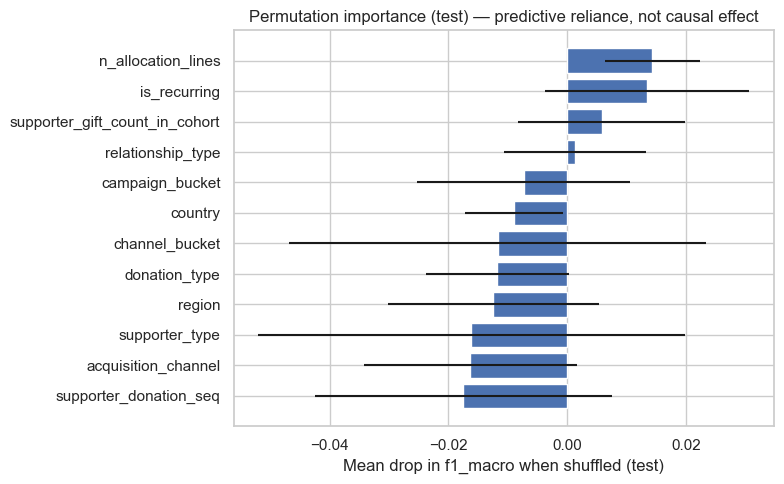

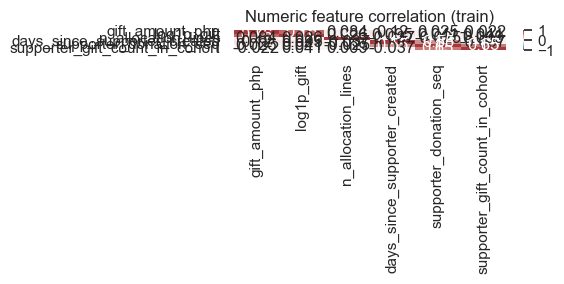

Raw columns with negative mean permutation importance: ['gift_amount_php', 'log1p_gift', 'days_since_supporter_created', 'supporter_donation_seq', 'donation_type', 'channel_bucket', 'campaign_bucket', 'supporter_type', 'region', 'country', 'acquisition_channel']
Test macro-F1 before prune: 0.3040 | after prune: 0.4085
Adopted pruned feature set and refitted model.
Test accuracy: 0.440
Test macro-F1: 0.409

Per-class report:
                           precision    recall  f1-score   support

Operations_and_facilities       0.54      0.50      0.52        42
      Outreach_and_growth       0.24      0.50      0.32         8
        Resident_programs       0.43      0.35      0.39        34

                 accuracy                           0.44        84
                macro avg       0.40      0.45      0.41        84
             weighted avg       0.47      0.44      0.45        84



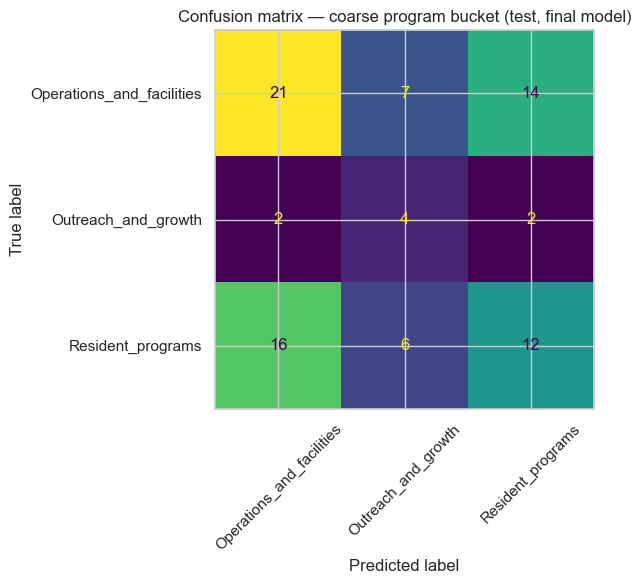


--- Binary benchmark: resident-facing (Education/Wellbeing) vs other ---
              precision    recall  f1-score   support

           0       0.56      0.38      0.45        50
           1       0.38      0.56      0.45        34

    accuracy                           0.45        84
   macro avg       0.47      0.47      0.45        84
weighted avg       0.49      0.45      0.45        84

ROC-AUC (test): 0.485


In [33]:
perm = permutation_importance(
    clf_pipe,
    X_test,
    y_test,
    n_repeats=25,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
    n_jobs=1,
)

imp = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(imp)

fig, ax = plt.subplots(figsize=(8, 5))
top = imp.head(12).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
ax.set_xlabel("Mean drop in f1_macro when shuffled (test)")
ax.set_title("Permutation importance (test) — predictive reliance, not causal effect")
plt.tight_layout()
plt.show()

_nc = [c for c in numeric_features if c in X_train.columns]
fig2, ax2 = plt.subplots(figsize=(max(4, len(_nc)), 3))
sns.heatmap(
    X_train[_nc].corr(),
    annot=True,
    ax=ax2,
    cmap="vlag",
    vmin=-1,
    vmax=1,
)
ax2.set_title("Numeric feature correlation (train)")
plt.tight_layout()
plt.show()

# --- §5b Ch.16: optional drop of negative permutation-importance raw columns ---
y_pred_base = clf_pipe.predict(X_test)
f1_base = float(f1_score(y_test, y_pred_base, average="macro"))

neg_cols = list(X_test.columns[perm.importances_mean < 0])
print("Raw columns with negative mean permutation importance:", neg_cols)

if len(neg_cols) == 0 or len(neg_cols) >= len(feature_cols) - 1:
    print("Pruning skipped (nothing to drop or would leave <2 features).")
else:
    feat_p = [c for c in feature_cols if c not in neg_cols]
    num_p = [c for c in numeric_features if c in feat_p]
    cat_p = [c for c in categorical_features if c in feat_p]
    Xtr_p = X_train[feat_p]
    Xte_p = X_test[feat_p]

    tree_p, scaled_p = make_preprocessors(num_p, cat_p)

    if best_name == "logistic":
        cand = Pipeline(
            steps=[
                ("prep", scaled_p),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=4000,
                        solver="lbfgs",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
    elif best_name == "random_forest":
        cand = Pipeline(
            steps=[
                ("prep", tree_p),
                (
                    "clf",
                    RandomForestClassifier(
                        random_state=RANDOM_STATE,
                        class_weight="balanced",
                        n_jobs=1,
                    ),
                ),
            ]
        )
    elif best_name == "hist_gradient_boosting":
        cand = Pipeline(
            steps=[
                ("prep", tree_p),
                (
                    "clf",
                    HistGradientBoostingClassifier(
                        random_state=RANDOM_STATE,
                        class_weight="balanced",
                    ),
                ),
            ]
        )
    else:
        cand = Pipeline(
            steps=[
                ("prep", tree_p),
                ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ]
        )

    cand.set_params(**best_gs.best_params_)
    cand.fit(Xtr_p, y_train)
    f1_pruned = float(f1_score(y_test, cand.predict(Xte_p), average="macro"))
    print(f"Test macro-F1 before prune: {f1_base:.4f} | after prune: {f1_pruned:.4f}")

    if f1_pruned >= f1_base:
        clf_pipe = cand
        feature_cols = feat_p
        numeric_features = num_p
        categorical_features = cat_p
        X_train, X_test = Xtr_p, Xte_p
        print("Adopted pruned feature set and refitted model.")
    else:
        print("Kept original model (pruned version did not improve test macro-F1).")

# --- §4 holdout metrics (run after optional §5b so acc/f1 match serialized clf_pipe) ---
y_pred = clf_pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")
print(f"Test accuracy: {acc:.3f}")
print(f"Test macro-F1: {f1m:.3f}")
print("\nPer-class report:")
print(classification_report(y_test, y_pred, zero_division=0))

fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax_cm, xticks_rotation=45, colorbar=False
)
ax_cm.set_title("Confusion matrix — coarse program bucket (test, final model)")
plt.tight_layout()
plt.show()

# Binary framing: resident-facing (Education/Wellbeing) vs everything else — same train/test rows
y_bin = raw["is_resident_facing_program"].astype(int)
y_bin_tr = y_bin.loc[X_train.index]
y_bin_te = y_bin.loc[X_test.index]
_, _sb = make_preprocessors(numeric_features, categorical_features)
pipe_bin = Pipeline(
    steps=[
        ("prep", _sb),
        (
            "clf",
            LogisticRegression(
                max_iter=4000,
                solver="lbfgs",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
pipe_bin.fit(X_train, y_bin_tr)
p_bin = pipe_bin.predict(X_test)
proba_bin = pipe_bin.predict_proba(X_test)[:, 1]
print("\n--- Binary benchmark: resident-facing (Education/Wellbeing) vs other ---")
print(classification_report(y_bin_te, p_bin, zero_division=0))
if y_bin_te.nunique() > 1:
    print(f"ROC-AUC (test): {roc_auc_score(y_bin_te, proba_bin):.3f}")


## 6. Deployment notes

**Integration (future, not implemented here).**

- **Batch scoring:** After gifts are posted in the ERP/database, an ETL job builds the same feature row and runs the serialized `Pipeline` to attach `predicted_primary_program` and `class_probabilities` for dashboard use.
- **API sketch:** `POST /api/ml/donor-impact/predict` with body fields matching `feature_cols` (donation + supporter attributes); response JSON: `{ "predicted_primary_program": "...", "probabilities": { ... } }`.
- **UI:** Donor portal “impact preview” card: “Based on gifts like yours, the largest share often supports **X**” with a disclaimer that actual allocations follow operations policy.
- **Ops:** Retrain on a schedule (e.g. quarterly), version `joblib` + metadata JSON, monitor confusion patterns as programs shift.

The next cell writes:
- **`donor_impact_model.joblib`** — fitted pipeline for on-demand scoring
- **`donor_impact_metadata.json`** — feature lists and metrics
- **`donor_impact_predictions.json`** — **one row per donation** with `donation_id`, `supporter_id`, `display_name`, **`predicted_primary_program_area`** (coarse **3-class bucket**), `predicted_probability`, **`actual_program_bucket`** (coarse truth), and **`actual_primary_program_area_fine`** (six-way label for QA)

No app code changes in this sprint.

In [34]:
ART = Path(".")
joblib.dump(clf_pipe, ART / "donor_impact_model.joblib")
meta = {
    "model": "multiclass_program_bucket_best_cv",
    "primary_estimator": best_name,
    "target": "primary_program_area_coarse (3 buckets; fine label = argmax allocation line)",
    "program_area_coarse_map": PROGRAM_AREA_COARSE,
    "extra_numeric_winsor_caps_train_p99": extra_caps,
    "features": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "train_n": int(len(X_train)),
    "test_n": int(len(X_test)),
    "cv_f1_macro_best": float(best_gs.best_score_),
    "best_params": best_gs.best_params_,
    "grid_cv_results": cv_results.to_dict(orient="records"),
    "test_accuracy": float(acc),
    "test_macro_f1": float(f1m),
    "gift_amount_winsor_p99_train": cap,
    "trained_at": datetime.now(timezone.utc).isoformat(),
}
with open(ART / "donor_impact_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, default=str)

# Dashboard export: predicted primary program per donation (same winsor + feature_cols as training)
X_all = raw[feature_cols].copy()
if "gift_amount_php" in X_all.columns:
    X_all["gift_amount_php"] = X_all["gift_amount_php"].clip(upper=cap)
if "log1p_gift" in X_all.columns and "gift_amount_php" in X_all.columns:
    X_all["log1p_gift"] = np.log1p(X_all["gift_amount_php"].clip(lower=0))
for _col, _ccap in extra_caps.items():
    if _col in X_all.columns:
        X_all[_col] = X_all[_col].clip(upper=_ccap)

pred_all = clf_pipe.predict(X_all)
proba_all = clf_pipe.predict_proba(X_all)
max_prob = proba_all.max(axis=1)

pred_df = pd.DataFrame(
    {
        "donation_id": raw["donation_id"].astype(int),
        "supporter_id": raw["supporter_id"].astype(int),
        "display_name": raw["display_name"].fillna("").astype(str),
        "donation_date": raw["donation_date"].astype(str),
        "predicted_primary_program_area": pred_all,
        "predicted_probability": max_prob,
        "actual_program_bucket": raw["primary_program_area_coarse"].astype(str),
        "actual_primary_program_area_fine": raw["primary_program_area"].astype(str),
    }
)
pred_path = ART / "donor_impact_predictions.json"
with open(pred_path, "w", encoding="utf-8") as f:
    json.dump(pred_df.to_dict(orient="records"), f, indent=2, default=str)

print("Wrote:", (ART / "donor_impact_model.joblib").resolve())
print("Wrote:", (ART / "donor_impact_metadata.json").resolve())
print("Wrote:", pred_path.resolve(), "| rows:", len(pred_df))
display(pred_df.head(10))


Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/donor_impact_model.joblib
Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/donor_impact_metadata.json
Wrote: /Users/joshuagoates/Documents/GitHub/Intex-II/ml-pipelines/donor_impact_predictions.json | rows: 420


,donation_id,supporter_id,display_name,donation_date,predicted_primary_program_area,predicted_probability,actual_program_bucket,actual_primary_program_area_fine
144,145,1,Mila Alvarez,2023-03-25,Resident_programs,0.733732,Resident_programs,Wellbeing
157,158,1,Mila Alvarez,2023-06-24,Resident_programs,0.733732,Resident_programs,Education
294,295,1,Mila Alvarez,2023-07-01,Operations_and_facilities,0.557000,Resident_programs,Education
14,15,1,Mila Alvarez,2023-07-02,Resident_programs,0.733732,Resident_programs,Education
147,148,1,Mila Alvarez,2023-07-23,Operations_and_facilities,0.557000,Operations_and_facilities,Maintenance
352,353,1,Mila Alvarez,2023-12-20,Resident_programs,0.733732,Resident_programs,Education
61,62,1,Mila Alvarez,2024-01-08,Operations_and_facilities,0.557000,Resident_programs,Wellbeing
160,161,1,Mila Alvarez,2024-10-17,Operations_and_facilities,0.557000,Operations_and_facilities,Transport
217,218,1,Mila Alvarez,2024-12-11,Operations_and_facilities,0.557000,Operations_and_facilities,Operations
142,143,1,Mila Alvarez,2025-10-29,Operations_and_facilities,0.557000,Resident_programs,Wellbeing


In [ ]:
# ── PRODUCTION: Write donor impact predictions to Azure SQL ──
if USE_DB:
    import datetime as _dt
    _model_version = _dt.date.today().isoformat()
    _now = _dt.datetime.utcnow()

    # Aggregate pred_df: count predictions per supporter × program_area, compute pct
    _agg = (
        pred_df.groupby(["supporter_id", "predicted_primary_program_area"])
        .size()
        .reset_index(name="n")
    )
    _totals = _agg.groupby("supporter_id")["n"].transform("sum")
    _agg["predicted_pct"] = (_agg["n"] / _totals * 100).round(1)

    _rows = []
    for _, _r in _agg.iterrows():
        _rows.append({
            "supporter_id":  int(_r["supporter_id"]),
            "program_area":  str(_r["predicted_primary_program_area"])[:50],
            "predicted_pct": float(_r["predicted_pct"]),
            "scored_at":     _now,
            "model_version": _model_version,
            "is_current":    1,
        })

    _impact_df = pd.DataFrame(_rows)

    with engine.begin() as _conn:
        _conn.execute(text("UPDATE ml_donor_impact_predictions SET is_current = 0 WHERE is_current = 1"))
        _impact_df.to_sql("ml_donor_impact_predictions", _conn, if_exists="append", index=False)

    print(f"✓ Wrote {len(_impact_df)} impact prediction rows for {_agg['supporter_id'].nunique()} donors (model v{_model_version})")
else:
    print("Skipping DB write — USE_DB is False")
